# 01 · 합성 PM 사고 데이터 생성기

**PM 사고 위험구역 예측 파일럿 — 데이터 생성 단계**

이 노트북은 **합성 사고 데이터셋을 만들어 CSV/GPKG로 저장**한다. 파일럿 노트북(`pilot.ipynb`)은 여기서 만든 파일을 *불러다 쓰기만* 한다 (생성 로직 분리).

## 왜 합성인가 — 확인된 사실
실제 PM 사고의 **점단위(위경도·시각) 공개 데이터가 존재하지 않는다.**
- data.go.kr 15123495 = `연도×법규위반` **집계표**(좌표·시각 없음) → 모델 레이블 불가.
- TAAS 사고다발지 OpenAPI = 자전거·보행자·이륜차 등은 있으나 **개인형이동장치(PM) 항목 자체가 없음**.
- 점단위 PM 사고(좌표·시각·기상)는 **한국교통안전공단 요청**으로만 확보 가능(본 파일럿의 결론).

따라서 실데이터 확보 전까지, **실제 구조·실제 날씨에 결합된 합성 사고**로 방법론을 검증한다.

## 생성 설계 (무작위가 아님)
- **공간**: 실제 대전 OSM 도로구조·상권(POI)·대학 근접으로 셀별 **잠재 노출량 `lat_expo`** 산출.
  `lat_expo = 0.85·(OSM 관측가능 구조성분) + 0.55·(OSM에 없는 독립성분 = 실제 PM 통행수요)`.
  → 구조는 노출을 *부분적으로만* 대리. 독립성분은 KT·공단 데이터만 채울 수 있는 정보.
- **시간·날씨**: 사고 발생 시각을 **실제 ASOS 날씨 타임라인**(`data/asos/`, 2019~2023)에서
  `시간대(저녁 피크)×주말×강수(실제 is_rain)×연도증가` 가중으로 샘플 → **사고가 실제 날씨에 결합**된다.

## 출력
- `data/grid_features.gpkg` — 셀 지오메트리 + 구조 피처 + `lat_expo`(+ 검증용 `hidden_demand`)
- `data/accidents_synth.csv` — 사고별 `datetime, cell_id, lat, lon, severity`

## 1. 환경 설정

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import geopandas as gpd
from shapely.geometry import box, Point
import osmnx as ox
import pmrisk

_avail = {f.name for f in fm.fontManager.ttflist}
for _c in ["Malgun Gothic", "NanumGothic", "Batang", "Gulim"]:
    if _c in _avail: mpl.rcParams["font.family"] = _c; break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.dpi"] = 110

SEED = 42
RNG = np.random.default_rng(SEED)
import os
os.makedirs(pmrisk.CACHE_DIR, exist_ok=True)
ox.settings.use_cache = True
ox.settings.cache_folder = os.path.join(pmrisk.CACHE_DIR, "osmnx")
print("font:", mpl.rcParams["font.family"])
print("기간:", pmrisk.YEARS)

font: ['Malgun Gothic']
기간: [2019, 2020, 2021, 2022, 2023]


## 2. 실제 대전 도로망·POI 수집 (OSM) + 500m 격자

In [2]:
W, S, E, N = pmrisk.BBOX
graph_path = os.path.join(pmrisk.CACHE_DIR, "daejeon_drive.graphml")
if os.path.exists(graph_path):
    G = ox.load_graphml(graph_path); src = "cache"
else:
    G = ox.graph_from_bbox((W, S, E, N), network_type="drive")
    ox.save_graphml(G, graph_path); src = "OSM live"
nodes, edges = ox.graph_to_gdfs(G)
print(f"[OSM:{src}] nodes={len(nodes)} edges={len(edges)}")

[OSM:cache] nodes=7883 edges=22264


In [3]:
# 격자
bbox_proj = gpd.GeoDataFrame(geometry=[box(W, S, E, N)], crs=pmrisk.GRID_CRS_WGS).to_crs(pmrisk.PROJ)
minx, miny, maxx, maxy = bbox_proj.total_bounds
xs = np.arange(minx, maxx, pmrisk.CELL_M); ys = np.arange(miny, maxy, pmrisk.CELL_M)
recs = []
for i, x in enumerate(xs):
    for j, y in enumerate(ys):
        recs.append({"cell_id": f"{i:02d}_{j:02d}", "ix": i, "iy": j,
                     "geometry": box(x, y, x + pmrisk.CELL_M, y + pmrisk.CELL_M)})
grid = gpd.GeoDataFrame(recs, crs=pmrisk.PROJ)
cent = grid.geometry.centroid
grid["cx"], grid["cy"] = cent.x, cent.y
cll = gpd.GeoDataFrame(geometry=cent, crs=pmrisk.PROJ).to_crs(pmrisk.GRID_CRS_WGS)
grid["lon"], grid["lat"] = cll.geometry.x.values, cll.geometry.y.values
print("격자 셀 수:", len(grid))

격자 셀 수: 456


In [4]:
# 셀별 도로 피처
def _is_art(h):
    h = h[0] if isinstance(h, list) else h
    return h in pmrisk.ARTERIAL
ep = edges.to_crs(pmrisk.PROJ).reset_index()
ep["seg_len"] = ep.geometry.length
ep["arterial"] = ep["highway"].apply(_is_art)
je = gpd.sjoin(ep[["seg_len", "arterial", "geometry"]], grid[["cell_id", "geometry"]],
               how="inner", predicate="intersects")
road = je.groupby("cell_id").agg(road_len=("seg_len", "sum"), n_edges=("seg_len", "size")).reset_index()
art = je[je["arterial"]].groupby("cell_id")["seg_len"].sum().rename("arterial_len").reset_index()
road = road.merge(art, on="cell_id", how="left")
npr = nodes.to_crs(pmrisk.PROJ).reset_index()
if "street_count" not in npr.columns: npr["street_count"] = 3
inter = npr[npr["street_count"] >= 3]
ji = gpd.sjoin(inter[["street_count", "geometry"]], grid[["cell_id", "geometry"]],
               how="inner", predicate="within")
icnt = ji.groupby("cell_id").size().rename("n_intersections").reset_index()
grid = grid.merge(road, on="cell_id", how="left").merge(icnt, on="cell_id", how="left")

# POI + 대학거리
tags = {"amenity": ["restaurant", "cafe", "bar", "pub", "fast_food", "university", "college", "school"]}
poi = ox.features_from_bbox((W, S, E, N), tags)
poi = poi[poi.geometry.notna()].to_crs(pmrisk.PROJ)
poi["geometry"] = poi.geometry.centroid
jp = gpd.sjoin(poi[["geometry"]], grid[["cell_id", "geometry"]], how="inner", predicate="within")
grid = grid.merge(jp.groupby("cell_id").size().rename("n_poi").reset_index(), on="cell_id", how="left")

uni = gpd.GeoDataFrame(geometry=[Point(lo, la) for la, lo in pmrisk.UNIV.values()],
                       crs=pmrisk.GRID_CRS_WGS).to_crs(pmrisk.PROJ)
cc = gpd.GeoDataFrame(geometry=gpd.points_from_xy(grid["cx"].values, grid["cy"].values), crs=pmrisk.PROJ)
grid["dist_univ"] = cc.geometry.apply(lambda g: float(uni.distance(g).min()))

for c in ["road_len", "arterial_len", "n_edges", "n_intersections", "n_poi"]:
    grid[c] = grid[c].fillna(0.0)
grid["intersection_density"] = grid["n_intersections"] / (pmrisk.CELL_M**2 / 1e6)
grid = grid.reset_index(drop=True)
print("도로/POI 피처 계산 완료:", pmrisk.STRUCT_FEATURES)

도로/POI 피처 계산 완료: ['road_len', 'arterial_len', 'n_edges', 'n_intersections', 'intersection_density', 'n_poi', 'dist_univ']


## 3. 잠재 노출량 `lat_expo` = 구조 성분 + 독립 성분(PM 실수요)

In [5]:
z = pmrisk.zscore
struct = (0.9*z(np.log1p(grid["road_len"])) + 1.0*z(grid["n_intersections"]) +
          1.2*z(np.log1p(grid["n_poi"])) + 1.1*z(np.exp(-grid["dist_univ"]/1200.0)))
hidden = RNG.normal(0, 1, len(grid))                 # OSM에 없는 실제 PM 통행수요
grid["struct_score"] = z(struct)
grid["hidden_demand"] = hidden
grid["lat_expo"] = 0.85*z(struct) + 0.55*z(hidden)   # 구조 ~70% + 실수요 ~30%
base = np.exp(1.0*grid["lat_expo"].values)           # 셀 상대 강도
print("lat_expo:", grid["lat_expo"].describe()[["min","mean","max"]].round(2).to_dict())

lat_expo: {'min': -2.63, 'mean': 0.0, 'max': 2.85}


## 4. 실제 ASOS 날씨 타임라인에 결합해 사고 시각 샘플링

In [6]:
w = pmrisk.load_weather()
w["hour"] = w.datetime.dt.hour
w["dow"] = w.datetime.dt.dayofweek
w["weekend"] = (w.dow >= 5).astype(int)
w["year"] = w.datetime.dt.year
w["daypart"] = w["hour"].map(pmrisk.daypart_of)
w["weight"] = (w["daypart"].map(pmrisk.DP_MULT)
               * np.where(w["weekend"] == 1, pmrisk.WEEKEND_MULT, 1.0)
               * np.where(w["is_rain"] == 1, pmrisk.RAIN_MULT, 1.0)
               * w["year"].map(pmrisk.YEAR_GROWTH))
pw = (w["weight"] / w["weight"].sum()).values
print(f"날씨 타임라인 {len(w)}시간 | 강수시간 {100*w.is_rain.mean():.1f}%")

날씨 타임라인 43824시간 | 강수시간 6.4%


In [7]:
TARGET_ACC = 4000
t_idx = RNG.choice(len(w), size=TARGET_ACC, p=pw)
c_idx = RNG.choice(len(grid), size=TARGET_ACC, p=base / base.sum())
acc = pd.DataFrame({
    "datetime": pd.to_datetime(w["datetime"].values[t_idx]),
    "cell_id": grid["cell_id"].values[c_idx],
    "lat": grid["lat"].values[c_idx] + RNG.normal(0, 0.0015, TARGET_ACC),
    "lon": grid["lon"].values[c_idx] + RNG.normal(0, 0.0018, TARGET_ACC),
    "severity": RNG.choice(pmrisk.SEVERITY, size=TARGET_ACC, p=pmrisk.SEVERITY_P),
}).sort_values("datetime").reset_index(drop=True)
acc.insert(0, "accident_id", np.arange(1, len(acc) + 1))
print("생성 사고:", len(acc))
acc.head()

생성 사고: 4000


,accident_id,datetime,cell_id,lat,lon,severity
0,1,2019-01-02 18:00:00,14_06,36.339395,127.378716,경상
1,2,2019-01-02 19:00:00,21_08,36.348170,127.417303,중상
2,3,2019-01-02 23:00:00,06_12,36.366753,127.337136,경상
3,4,2019-01-03 17:00:00,13_09,36.351981,127.372297,경상
4,5,2019-01-04 05:00:00,10_12,36.364150,127.355995,경상


## 5. 생성 점검 (실제 날씨 결합 확인)

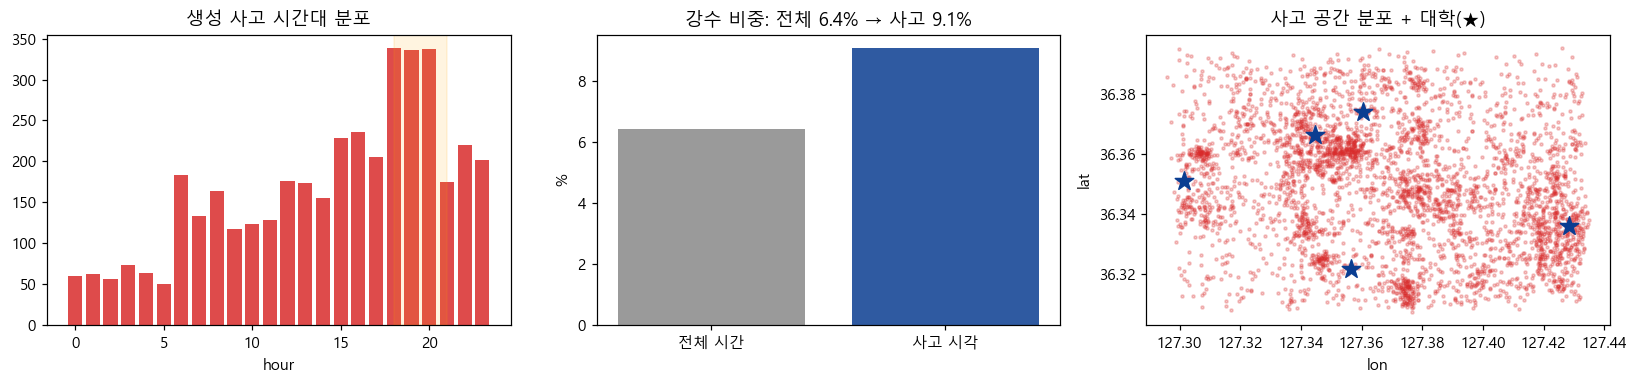

→ 강수 비중이 전체(6.4%)보다 사고 시각(9.1%)에서 높음 = 날씨 결합 정상


In [8]:
# 사고 시각에 실제 날씨 join → 강수/시간대 결합이 실제로 반영됐는지 확인
chk = acc.merge(w[["datetime", "is_rain", "hour"]], on="datetime", how="left")
base_rain = w["is_rain"].mean()
acc_rain = chk["is_rain"].mean()
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].bar(chk.groupby("hour").size().index, chk.groupby("hour").size().values, color="#D92B2B", alpha=0.85)
ax[0].axvspan(18, 21, color="orange", alpha=0.12); ax[0].set_title("생성 사고 시간대 분포"); ax[0].set_xlabel("hour")
ax[1].bar(["전체 시간", "사고 시각"], [base_rain*100, acc_rain*100], color=["#888", "#0A3D91"], alpha=0.85)
ax[1].set_title(f"강수 비중: 전체 {base_rain*100:.1f}% → 사고 {acc_rain*100:.1f}%"); ax[1].set_ylabel("%")
ax[2].scatter(acc["lon"], acc["lat"], s=4, alpha=0.25, color="#D92B2B")
for nm,(la,lo) in pmrisk.UNIV.items(): ax[2].scatter(lo, la, marker="*", s=160, color="#0A3D91", zorder=5)
ax[2].set_title("사고 공간 분포 + 대학(★)"); ax[2].set_xlabel("lon"); ax[2].set_ylabel("lat")
plt.tight_layout(); plt.show()
print(f"→ 강수 비중이 전체({base_rain*100:.1f}%)보다 사고 시각({acc_rain*100:.1f}%)에서 높음 = 날씨 결합 정상")

## 6. 저장 — 파일럿이 불러다 쓸 파일

In [9]:
grid.to_file(pmrisk.GRID_GPKG, driver="GPKG")
acc.to_csv(pmrisk.ACCIDENTS_CSV, index=False, encoding="utf-8-sig")
print("저장 완료:")
print(" -", pmrisk.GRID_GPKG, f"({len(grid)} cells, {len(grid.columns)} cols)")
print(" -", pmrisk.ACCIDENTS_CSV, f"({len(acc)} accidents)")
print("\n날씨는 저장하지 않음 — 파일럿이 data/asos/ 실데이터를 직접 join.")

저장 완료:
 - data\grid_features.gpkg (456 cells, 18 cols)
 - data\accidents_synth.csv (4000 accidents)

날씨는 저장하지 않음 — 파일럿이 data/asos/ 실데이터를 직접 join.
